# Project: Loan Default Prediction

In [53]:
# Core Libraries
import pandas as pd 
import numpy as np 

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Model Saving
import joblib

# 1. Load Data

In [54]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

# 2. Data Exploration

In [55]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [56]:
train_df.shape

(614, 13)

In [57]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [58]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [59]:
list(train_df.columns)

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [60]:
train_df['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

In [61]:
# Checking Duplicate Values 
train_df.duplicated().sum()

np.int64(0)

In [62]:
train_df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

# 3. Check Missing Values

In [63]:
train_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [64]:
# in percentage 
(train_df.isnull().sum() / len(train_df)) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [65]:
# in percentage (order=Descending)
((train_df.isnull().sum() / len(train_df)) * 100).sort_values(ascending=False)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

# 4. Handle Missing Values

### 4.1 For Train Dataset

In [66]:
# Imputing Null Values
for col in train_df.columns:  
    if train_df[col].dtype == "object": 
        train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    else: 
        train_df[col] = train_df[col].fillna(train_df[col].median()) 

In [67]:
# Checking Null vals after Imputing Missing Vals
train_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### 4.2 For Test Dataset

In [68]:
# Imputing Null Values
for col in test_df.columns: 
    if test_df[col].dtype == "object": 
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])
    else: 
        test_df[col] = test_df[col].fillna(test_df[col].median()) 

In [69]:
# Checking Null vals after Imputing Missing Vals 
test_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

# 5. EDA

### 5.1 Target distribution

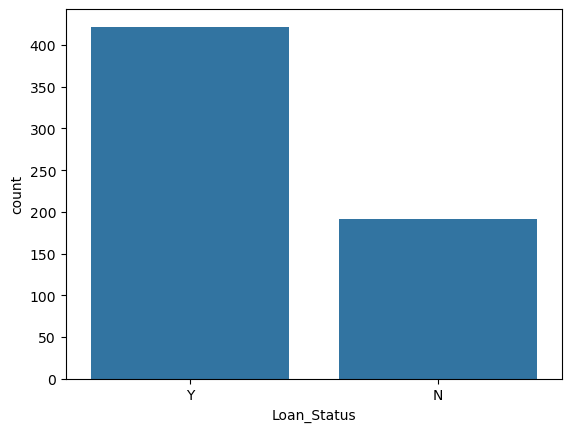

In [70]:
sns.countplot(x='Loan_Status', data=train_df)
plt.show()

### 5.2 Credit History vs Loan Status

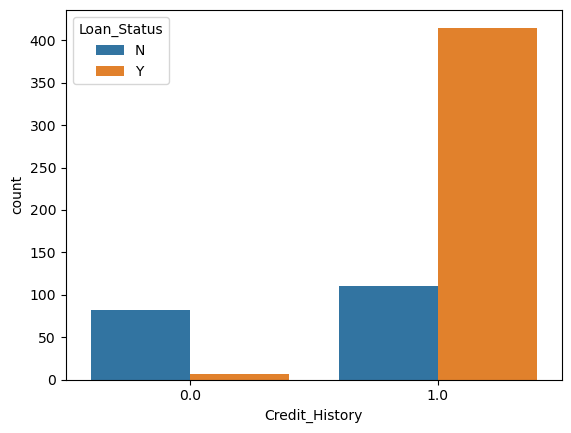

In [71]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=train_df)
plt.show()

### 5.3 Income Distribution

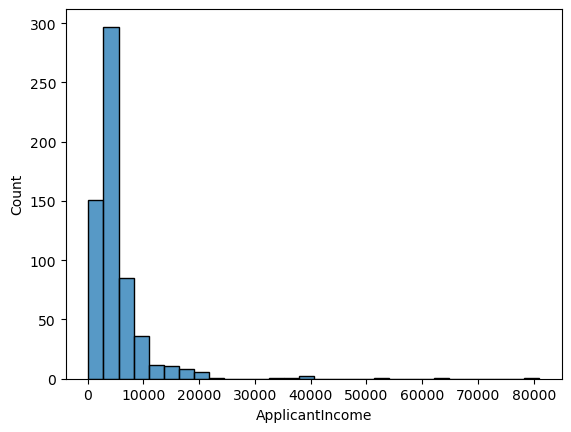

In [72]:
sns.histplot(train_df['ApplicantIncome'], bins=30)
plt.show()

### 5.4 Class Imbalance Analysis

In [73]:
train_df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [74]:
# in Percentage
train_df["Loan_Status"].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

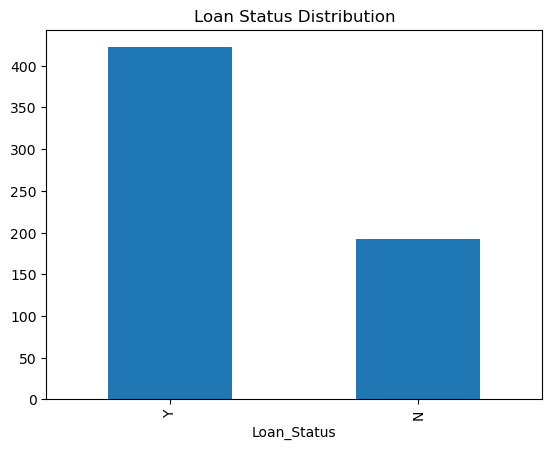

In [75]:
train_df["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

# 6. Handle "Dependents" Column

In [76]:
# Replacing value to perform type casting 
train_df["Dependents"] = train_df["Dependents"].replace("3+", 3)
test_df["Dependents"] = test_df["Dependents"].replace("3+", 3)

In [77]:
# Check unique val of "Dependents" col in both datasets 
print("in train_df: ", train_df["Dependents"].unique())
print("in test_df: ", test_df["Dependents"].unique())

in train_df:  ['0' '1' '2' 3]
in test_df:  ['0' '1' '2' 3]


In [78]:
# Check missing value 
print("in train_df:", train_df['Dependents'].isnull().sum())
print("in test_df:", test_df['Dependents'].isnull().sum())

in train_df: 0
in test_df: 0


### 6.1 Convert to numeric

In [79]:
train_df["Dependents"] = train_df["Dependents"].astype(int)
test_df["Dependents"] = test_df["Dependents"].astype(int)

In [80]:
# Check updated data after Type Casting 
print(" 'Dependents' in train_df: ", train_df["Dependents"].unique())
print(" 'Dependents' in test_df: ", test_df["Dependents"].unique())

 'Dependents' in train_df:  [0 1 2 3]
 'Dependents' in test_df:  [0 1 2 3]


# 7. Droping Irrelevent Feature Column

In [81]:
# Droping "Loan_ID" column from train_df
train_df.drop("Loan_ID", axis=1, inplace=True)

# Storing "Loan_ID" column from test_df for mapping predictions in final output
test_ids = test_df["Loan_ID"]

# Droping "Loan_ID" column from test_df
test_df.drop("Loan_ID", axis=1, inplace=True)

# 8. Features and Target Split

In [82]:
X = train_df.drop("Loan_Status", axis=1)
y = train_df["Loan_Status"]

# 9. Train-Test Split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

# 10. Feature Engineering

### 10.1 Check Number of Unique Val in Each Col

In [84]:
train_df.nunique()

Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

### 10.2 Splitting Categorical Features (Binary vs Multi-Category)

In [85]:
binary_cols = []  # for the col which has 2 unique vals
multi_cat_cols = []  # for the col which has more than 2 unique vals

for col in X.columns:
    if X[col].dtype == "object":
        if X[col].nunique() == 2:
            binary_cols.append(col)
        else:
            multi_cat_cols.append(col)

print("Binary:", binary_cols)
print("Multi-category:", multi_cat_cols)

Binary: ['Gender', 'Married', 'Education', 'Self_Employed']
Multi-category: ['Property_Area']


### 10.3 Label Encoding (ONLY binary categorical columns)

In [86]:
le = LabelEncoder()

for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col]) 
    test_df[col] = le.transform(test_df[col])

### 10.4 One-Hot Encoding (Only Property_Area column)

In [87]:
X_train = pd.get_dummies(X_train, columns=multi_cat_cols, drop_first=True)

X_test = pd.get_dummies(X_test, columns=multi_cat_cols, drop_first=True)

test_df = pd.get_dummies(test_df, columns=multi_cat_cols, drop_first=True)

### 10.5 Aligning Test Features with Training Data

In [88]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
test_df = test_df.reindex(columns=X.columns, fill_value=0)

# 11. Feature Scaling

In [89]:
scaler = StandardScaler() 

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-2.249829,-1.412056,-0.758535,-0.521556,-0.390618,-0.370409,-0.594953,-1.376096,0.273044,0.40436,-0.767461,1.431674
1,0.444478,0.708187,2.228957,-0.521556,2.560048,0.690643,-0.594953,1.285864,0.273044,0.40436,1.302997,-0.698483
2,0.444478,0.708187,0.237296,-0.521556,-0.390618,-0.424984,0.090958,-0.299739,2.148072,0.40436,1.302997,-0.698483
3,0.444478,-1.412056,-0.758535,-0.521556,-0.390618,-0.050802,-0.594953,-0.149280,0.273044,0.40436,-0.767461,1.431674
4,-2.249829,-1.412056,-0.758535,-0.521556,-0.390618,-0.381324,0.515977,-0.195575,0.273044,0.40436,-0.767461,-0.698483


# 12. Model Training

### 12.1 Logistic Regression

In [91]:
lr = LogisticRegression(random_state=2, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [92]:
# Accuracy Score 
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")

Logistic Regression Accuracy: 80.49%


In [93]:
# Classification report 
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           N       0.82      0.47      0.60        38
           Y       0.80      0.95      0.87        85

    accuracy                           0.80       123
   macro avg       0.81      0.71      0.74       123
weighted avg       0.81      0.80      0.79       123



### 12.2 Decission Tree

In [94]:
dt = DecisionTreeClassifier(random_state=2)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [95]:
# Accuracy Score 
print(f"Decission Tree Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")

Decission Tree Accuracy: 77.24%


In [96]:
# Classification report 
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           N       0.62      0.68      0.65        38
           Y       0.85      0.81      0.83        85

    accuracy                           0.77       123
   macro avg       0.74      0.75      0.74       123
weighted avg       0.78      0.77      0.78       123



### 12.3 Random Forest

In [97]:
rf = RandomForestClassifier(random_state=2, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [98]:
# Accuracy Score 
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")

Random Forest Accuracy: 78.05%


In [99]:
# Classification report 
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           N       0.70      0.50      0.58        38
           Y       0.80      0.91      0.85        85

    accuracy                           0.78       123
   macro avg       0.75      0.70      0.72       123
weighted avg       0.77      0.78      0.77       123



### 12.4 Model Comparison

In [100]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr) * 100, 2),
        round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        round(accuracy_score(y_test, y_pred_rf) * 100, 2)
    ]
}

pd.DataFrame(results).sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,80.49
2,Random Forest,78.05
1,Decision Tree,77.24


### 12.5 ROC AUC Score

In [101]:
from sklearn.metrics import roc_auc_score
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]):.4f}")

ROC-AUC: 0.7427


# 13. Confusion Matrix 

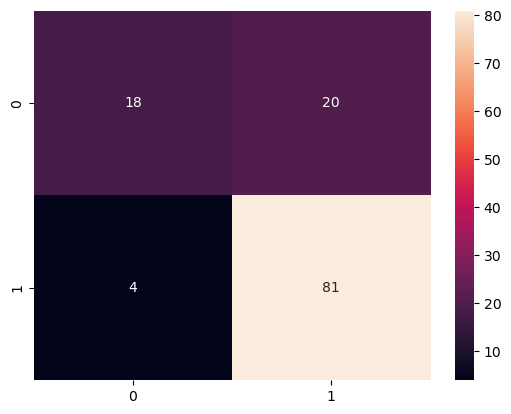

In [102]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# 14. Model Saving

### Saving Logistic Regression Model

In [103]:
joblib.dump(lr, '../models/loan_default_model.pkl')

['../models/loan_default_model.pkl']

### Saving Scaler

In [104]:
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']